In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes
from qiskit.visualization import plot_histogram

In [2]:
simulator = AerSimulator()

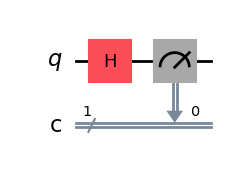

In [3]:
# implement the circuit

qc = QuantumCircuit(1, 1)

qc.h(0)

qc.measure(0, 0)

qc.draw(output='mpl')

In [4]:
pqc = transpile(qc, simulator)
job = simulator.run(qc, shots=1000)

In [5]:
job_result = job.result()


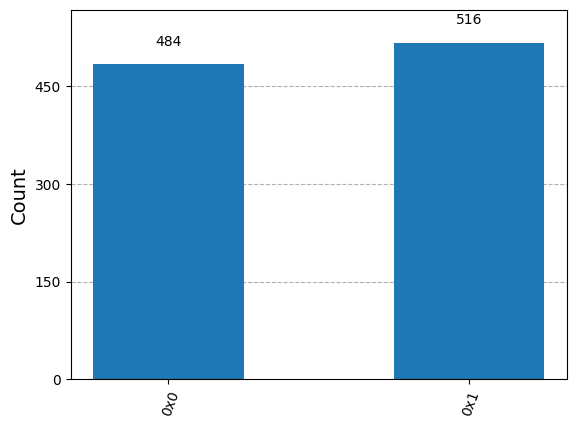

In [6]:
# extract the counts
counts = job_result.results[0].data.counts

#plt.hist(['0x0', '0x1'], weights=[counts['0x0'], counts['0x1']])
plot_histogram(counts)